In [44]:
import sys
import os

# Get project root (one level above notebooks folder)
project_root = os.path.abspath("E:\DV Data Science\credit-default-forecasting-system")

if project_root not in sys.path:
    sys.path.append(project_root)

print("Added to path:", project_root)

Added to path: E:\DV Data Science\credit-default-forecasting-system


# LOAD THE NECESSARY DATASETS

In [45]:
import pandas as pd
import numpy as np

In [46]:
# model comparison df
model_comparison=pd.read_csv(r"E:\DV Data Science\credit-default-forecasting-system\data\processed\model_comparision_wf.csv")

In [47]:
# monthly default rate dataframe
monthly_default_rate=pd.read_csv(r"E:\DV Data Science\credit-default-forecasting-system\data\processed\monthly_default_rate_cleaned.csv")

In [48]:
monthly_default_rate.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 115 entries, 0 to 114
Data columns (total 4 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   issue_month     115 non-null    object 
 1   total_loans     115 non-null    int64  
 2   total_defaults  115 non-null    int64  
 3   default_rate    115 non-null    float64
dtypes: float64(1), int64(2), object(1)
memory usage: 3.7+ KB


In [49]:
monthly_default_rate['issue_month']=pd.to_datetime(monthly_default_rate["issue_month"])

In [50]:
monthly_default_rate=monthly_default_rate.set_index("issue_month")

# TRAIN THE XGBOOST MODEL

In [51]:
!pip install xgboost

In [52]:
from src.models import xgboost_model as xm

In [53]:
from src.evaluation import metrics as mt
from src.evaluation import walk_forward_forecast as wf

In [54]:
actual_xgb,precited_xgb=wf.walk_forward_forecast(monthly_default_rate["default_rate"],"2014-12-01",xm.xgb_train,xm.xgb_forecast)

# EVALUATE THE MODEL

In [55]:
xgb_metrics=list(mt.evaluate_model(actual_xgb,precited_xgb))

D TYPE OF issue_month
2014-12-01    0.166974
2015-01-01    0.183297
2015-02-01    0.176273
2015-03-01    0.187323
2015-04-01    0.183024
2015-05-01    0.183154
2015-06-01    0.184799
2015-07-01    0.179692
2015-08-01    0.175082
2015-09-01    0.179393
2015-10-01    0.167136
2015-11-01    0.172102
2015-12-01    0.181133
2016-01-01    0.166625
2016-02-01    0.167649
2016-03-01    0.168248
2016-04-01    0.166118
2016-05-01    0.164173
2016-06-01    0.149732
2016-07-01    0.162209
2016-08-01    0.156340
2016-09-01    0.145075
2016-10-01    0.125168
2016-11-01    0.128213
2016-12-01    0.128513
Name: default_rate, dtype: float64: float64
D TYPE OF issue_month
2014-12-01    0.168540
2015-01-01    0.167195
2015-02-01    0.178447
2015-03-01    0.175388
2015-04-01    0.183910
2015-05-01    0.181375
2015-06-01    0.182570
2015-07-01    0.183419
2015-08-01    0.180146
2015-09-01    0.176341
2015-10-01    0.178079
2015-11-01    0.167242
2015-12-01    0.173392
2016-01-01    0.180176
2016-02-01    0

In [56]:
xgb_metrics

[np.float64(0.008683047287162547),
 np.float64(0.006570558129442342),
 np.float64(0.04180837360156809)]

In [57]:
model_comparison["XGBOOST"]=pd.Series(xgb_metrics,index=model_comparison.index)

In [58]:
model_comparison

,Unnamed: 0,NAIVE,MA3,MA6,"ARIMA(1,0,0)","ARIMA(2,0,0)","ARIMA(1,0,1)","ARIMA(2,0,1)","ARIMA(1,0,0) WALK FORWARD","ARIMA(2,0,0) WALK FORWARD","ARIMA(1,0,1) WALK FORWARD","ARIMA(2,0,1) WALK FORWARD",XGBOOST
0,RMSE,0.008974,0.009251,0.011536,0.017849,0.017352,0.017403,0.017516,0.009638,0.009243,0.009318,0.009282,0.008683
1,MAE,0.007011,0.006503,0.008902,0.014261,0.013882,0.013819,0.014173,0.007477,0.006949,0.007041,0.007029,0.006571
2,MAPE,0.043621,0.042823,0.059066,0.091761,0.089415,0.089200,0.090930,0.047715,0.044657,0.045258,0.044940,0.041808


In [59]:
model_comparison.drop(['ARIMA(1,0,0)','ARIMA(2,0,0)','ARIMA(1,0,1)','ARIMA(2,0,1)'],axis=1,inplace=True)

# PLOT THE ACTUAL VS PREDICTED GRAPHS

In [60]:
import matplotlib.pyplot as plt

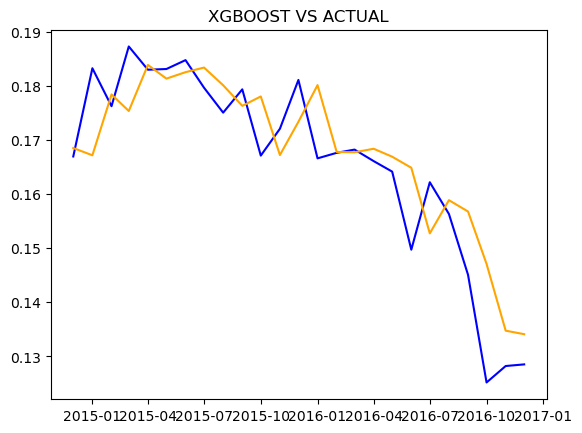

In [61]:
plt.plot(actual_xgb.index,actual_xgb,color='blue')
plt.plot(actual_xgb.index,precited_xgb,color='orange')
plt.title("XGBOOST VS ACTUAL")
plt.savefig(r"E:\DV Data Science\credit-default-forecasting-system\reports\figures\XGBOOST_VS_ACTUAL.png",dpi=300, bbox_inches="tight")
plt.show()

# TRAIN THE LIGHTGBM MODEL

In [62]:
pip install lightgbm

Note: you may need to restart the kernel to use updated packages.


In [63]:
from src.models import lightgbm_model as lm

In [64]:
from src.evaluation import metrics as mt
from src.evaluation import walk_forward_forecast as wf

In [65]:
actual_lgbm,precited_lgbm=wf.walk_forward_forecast(monthly_default_rate["default_rate"],"2014-12-01",lm.lgb_train,lm.lgb_forecast)

# EVALUATE MODEL LIGHTGBM

In [66]:
lightgbm_metrics=list(mt.evaluate_model(actual_lgbm,precited_lgbm))

D TYPE OF issue_month
2014-12-01    0.166974
2015-01-01    0.183297
2015-02-01    0.176273
2015-03-01    0.187323
2015-04-01    0.183024
2015-05-01    0.183154
2015-06-01    0.184799
2015-07-01    0.179692
2015-08-01    0.175082
2015-09-01    0.179393
2015-10-01    0.167136
2015-11-01    0.172102
2015-12-01    0.181133
2016-01-01    0.166625
2016-02-01    0.167649
2016-03-01    0.168248
2016-04-01    0.166118
2016-05-01    0.164173
2016-06-01    0.149732
2016-07-01    0.162209
2016-08-01    0.156340
2016-09-01    0.145075
2016-10-01    0.125168
2016-11-01    0.128213
2016-12-01    0.128513
Name: default_rate, dtype: float64: float64
D TYPE OF issue_month
2014-12-01    0.171020
2015-01-01    0.169399
2015-02-01    0.172294
2015-03-01    0.171790
2015-04-01    0.174913
2015-05-01    0.176247
2015-06-01    0.177252
2015-07-01    0.177146
2015-08-01    0.178585
2015-09-01    0.177248
2015-10-01    0.177077
2015-11-01    0.172926
2015-12-01    0.177105
2016-01-01    0.182109
2016-02-01    0

In [67]:
model_comparison["LightGBM"]=pd.Series(lightgbm_metrics,index=model_comparison.index)

In [68]:
model_comparison

,Unnamed: 0,NAIVE,MA3,MA6,"ARIMA(1,0,0) WALK FORWARD","ARIMA(2,0,0) WALK FORWARD","ARIMA(1,0,1) WALK FORWARD","ARIMA(2,0,1) WALK FORWARD",XGBOOST,LightGBM
0,RMSE,0.008974,0.009251,0.011536,0.009638,0.009243,0.009318,0.009282,0.008683,0.009464
1,MAE,0.007011,0.006503,0.008902,0.007477,0.006949,0.007041,0.007029,0.006571,0.007568
2,MAPE,0.043621,0.042823,0.059066,0.047715,0.044657,0.045258,0.044940,0.041808,0.047769


# PLOT ACTUAL VS PREDICTED LIGHTGBM

In [69]:
actual_lgbm,precited_lgbm

(issue_month
 2014-12-01    0.166974
 2015-01-01    0.183297
 2015-02-01    0.176273
 2015-03-01    0.187323
 2015-04-01    0.183024
 2015-05-01    0.183154
 2015-06-01    0.184799
 2015-07-01    0.179692
 2015-08-01    0.175082
 2015-09-01    0.179393
 2015-10-01    0.167136
 2015-11-01    0.172102
 2015-12-01    0.181133
 2016-01-01    0.166625
 2016-02-01    0.167649
 2016-03-01    0.168248
 2016-04-01    0.166118
 2016-05-01    0.164173
 2016-06-01    0.149732
 2016-07-01    0.162209
 2016-08-01    0.156340
 2016-09-01    0.145075
 2016-10-01    0.125168
 2016-11-01    0.128213
 2016-12-01    0.128513
 Name: default_rate, dtype: float64,
 issue_month
 2014-12-01    0.171020
 2015-01-01    0.169399
 2015-02-01    0.172294
 2015-03-01    0.171790
 2015-04-01    0.174913
 2015-05-01    0.176247
 2015-06-01    0.177252
 2015-07-01    0.177146
 2015-08-01    0.178585
 2015-09-01    0.177248
 2015-10-01    0.177077
 2015-11-01    0.172926
 2015-12-01    0.177105
 2016-01-01    0.182109
 

C:\Users\owner's\AppData\Local\Temp\ipykernel_33924\702492055.py:6: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


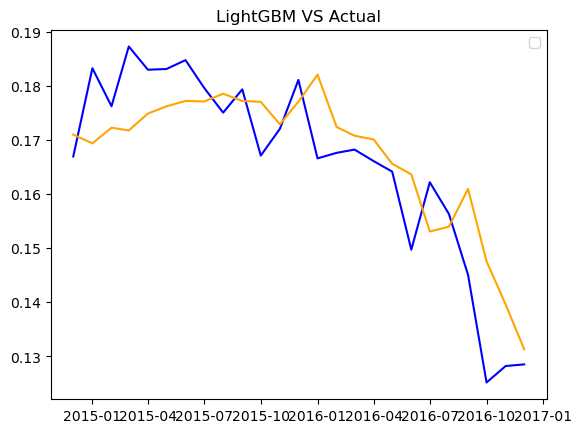

In [70]:
plt.plot(actual_lgbm.index,actual_lgbm,color='blue')
plt.plot(actual_lgbm.index,precited_lgbm,color='orange')
plt.title("LightGBM VS Actual")
label="Actual"
label="LightGBM Forecast"
plt.legend()
plt.savefig(r"E:\DV Data Science\credit-default-forecasting-system\reports\figures\LightGBM_VS_ACTUAL.png",dpi=300, bbox_inches="tight")
plt.show()

In [71]:
model_comparison

,Unnamed: 0,NAIVE,MA3,MA6,"ARIMA(1,0,0) WALK FORWARD","ARIMA(2,0,0) WALK FORWARD","ARIMA(1,0,1) WALK FORWARD","ARIMA(2,0,1) WALK FORWARD",XGBOOST,LightGBM
0,RMSE,0.008974,0.009251,0.011536,0.009638,0.009243,0.009318,0.009282,0.008683,0.009464
1,MAE,0.007011,0.006503,0.008902,0.007477,0.006949,0.007041,0.007029,0.006571,0.007568
2,MAPE,0.043621,0.042823,0.059066,0.047715,0.044657,0.045258,0.044940,0.041808,0.047769


### Final Model Selection

Based on the walk-forward backtesting results, **XGBoost** is selected as the final forecasting model. It achieved the lowest RMSE and MAPE among all evaluated models, indicating superior predictive performance in capturing the dynamics of the portfolio default rate.

# RESIDUAL DIAGONOSTICS

In [72]:
residual=actual_xgb-precited_xgb

In [73]:
residual=residual.rename("residuals")

In [74]:
residual.to_csv(r"E:\DV Data Science\credit-default-forecasting-system\data\processed\residuals.csv")

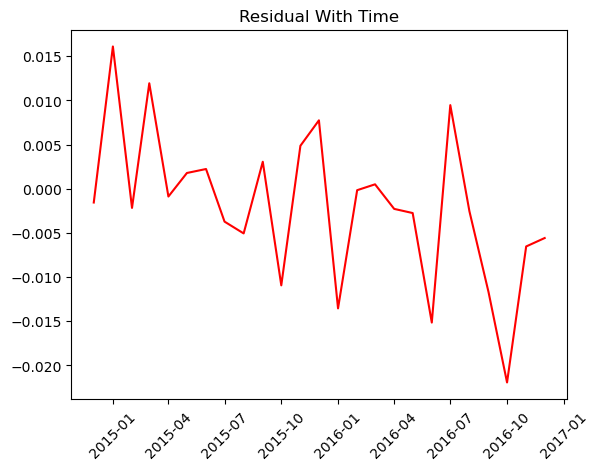

In [75]:
# Time plot for residual
plt.plot(residual.index,residual,color='red')
plt.title("Residual With Time")
plt.xticks(rotation=45)
plt.savefig(r"E:\DV Data Science\credit-default-forecasting-system\reports\figures\Residual_Time_Plot.png",dpi=300, bbox_inches="tight")
plt.show()

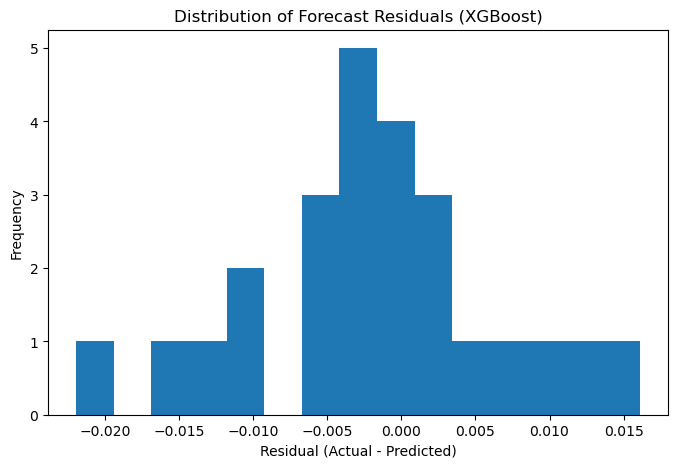

In [76]:
# Histogram for residulas
plt.figure(figsize=(8,5))
plt.hist(residual, bins=15)

plt.title("Distribution of Forecast Residuals (XGBoost)")
plt.xlabel("Residual (Actual - Predicted)")
plt.ylabel("Frequency")
plt.savefig(r"E:\DV Data Science\credit-default-forecasting-system\reports\figures\Residual_Histogram.png",dpi=300, bbox_inches="tight")
plt.show()

In [77]:
# Plot ACF and PACF
from statsmodels.graphics.tsaplots import plot_acf
from statsmodels.graphics.tsaplots import plot_pacf

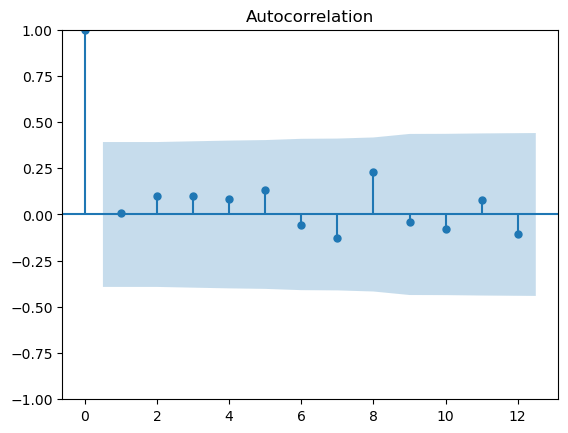

In [78]:
plot_acf(residual, lags=12)
plt.show()

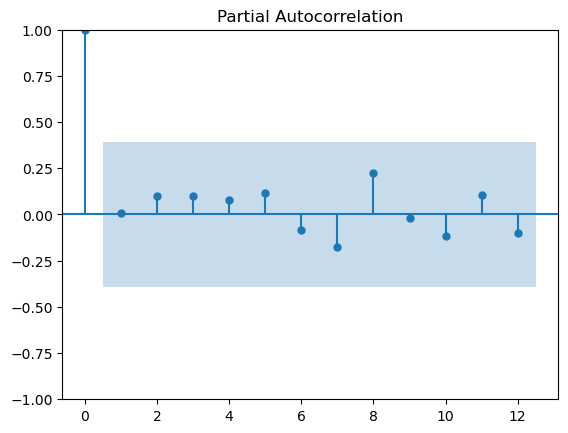

In [79]:
plot_pacf(residual, lags=12)
plt.show()

In [80]:
residual.mean()

np.float64(-0.0019580420433049674)

In [81]:
residual.std()

0.00863383494044838

## Notebook Summary: Model Development and Diagnostics

In this notebook, we developed and evaluated multiple forecasting models for predicting the monthly portfolio default rate.

### 1. Baseline Models
We first implemented simple benchmark models including:
- Naive Forecast
- Moving Average (MA3)
- Moving Average (MA6)

These models establish baseline performance levels that more sophisticated models must outperform.

### 2. ARIMA Models
Several ARIMA specifications were tested using walk-forward backtesting:
- ARIMA(1,0,0)
- ARIMA(2,0,0)
- ARIMA(1,0,1)
- ARIMA(2,0,1)

Walk-forward validation was used to simulate real-world forecasting conditions where the model is retrained as new data becomes available.

### 3. Machine Learning Models
To capture potential nonlinear relationships and interactions between past values, we implemented tree-based machine learning models using engineered features:

Feature set used:
- Lag features (lag_1 to lag_12)
- Rolling mean features (3-month and 6-month)
- Rolling standard deviation (6-month volatility)

Two gradient boosting models were evaluated:
- XGBoost
- LightGBM

### 4. Model Selection
Based on walk-forward evaluation metrics (RMSE, MAE, and MAPE), **XGBoost achieved the best overall forecasting performance**, outperforming both the baseline and ARIMA models.

This suggests that the gradient boosting model was able to capture nonlinear patterns and interactions between lagged values and rolling statistics more effectively than the traditional statistical models.

### 5. Residual Diagnostics

To validate the forecasting model, residual diagnostics were performed on the XGBoost predictions.

**Residual Time Plot**

The residuals fluctuate randomly around zero without any clear trend or structural pattern. This indicates that the model has captured most of the predictable structure in the time series.

**Residual Distribution**

The distribution of residuals is approximately symmetric and centered around zero, suggesting that the model does not systematically overpredict or underpredict the default rate.

**Residual Autocorrelation (ACF / PACF)**

The autocorrelation and partial autocorrelation plots of the residuals show no significant spikes outside the confidence intervals. This indicates that the residuals behave approximately as white noise, meaning that little temporal dependence remains unexplained by the model.

### 6. Residual Statistics

Mean residual: approximately zero  
Residual standard deviation: approximately 0.0086

A mean residual close to zero indicates that the forecasts are **unbiased on average**, while the small standard deviation suggests relatively low forecasting error.

### Conclusion

Overall, the XGBoost model demonstrates strong forecasting performance and passes key residual diagnostics, indicating that it effectively captures the main dynamics of the portfolio default rate series. As a result, XGBoost is selected as the final forecasting model for this project.